# Final Research-Grade CatBoost Thunderstorm Forecasting

## Pipeline

1. Load train (2000–2020), validation (2021–2022), test (2023–2025)
2. Time-series cross-validation on 2000–2020
3. Optuna hyperparameter tuning
4. Search multiple class weights
5. Optimize probability threshold
6. Optimize **CSI (Threat Score)** while enforcing a minimum Recall
7. Retrain on full 2000–2020
8. Select threshold using 2021–2022
9. Final evaluation on untouched 2023–2025
10. SHAP analysis
11. Save model & predictions


In [4]:

import pandas as pd
import numpy as np
import optuna
import shap
import joblib
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import *
from catboost import CatBoostClassifier

DATA=Path("../Data")

train=pd.read_csv(DATA/"train_2000_2020.csv")
valid=pd.read_csv(DATA/"validation_2021_2022.csv")
test=pd.read_csv(DATA/"test_2023_2025.csv")

DROP=["Thunderstorm_24h","Date","Time"]

X=train.drop(columns=DROP)
y=train["Thunderstorm_24h"]

X_valid=valid.drop(columns=DROP)
y_valid=valid["Thunderstorm_24h"]

X_test=test.drop(columns=DROP)
y_test=test["Thunderstorm_24h"]


In [2]:

weights=[[1,1],[1,1.2],[1,1.5],[1,1.8],[1,2],[1,2.5],[1,3]]

def weather_scores(y_true,y_pred):
    tn,fp,fn,tp=confusion_matrix(y_true,y_pred).ravel()
    precision=tp/(tp+fp) if tp+fp else 0
    recall=tp/(tp+fn) if tp+fn else 0
    far=fp/(tp+fp) if tp+fp else 0
    csi=tp/(tp+fp+fn) if tp+fp+fn else 0
    f1=f1_score(y_true,y_pred,zero_division=0)
    return precision,recall,far,csi,f1


In [ ]:

best_score=-1
best_weight=None
best_params=None

for cw in weights:

    def objective(trial):

        params=dict(
            iterations=trial.suggest_int("iterations",1000,3000),
            depth=trial.suggest_int("depth",4,10),
            learning_rate=trial.suggest_float("learning_rate",0.01,0.15,log=True),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg",1,15),
            random_strength=trial.suggest_float("random_strength",0,10),
            bagging_temperature=trial.suggest_float("bagging_temperature",0,5),
            border_count=trial.suggest_int("border_count",64,255),
            class_weights=cw,
            loss_function="Logloss",
            verbose=False,
            random_seed=42
        )

        tscv=TimeSeriesSplit(n_splits=4)
        scores=[]

        for tr_idx,val_idx in tscv.split(X):

            X_tr=X.iloc[tr_idx]
            X_va=X.iloc[val_idx]

            y_tr=y.iloc[tr_idx]
            y_va=y.iloc[val_idx]

            model=CatBoostClassifier(**params)
            model.fit(X_tr,y_tr)

            prob=model.predict_proba(X_va)[:,1]

            best_fold=0

            for thr in np.arange(0.20,0.81,0.02):

                pred=(prob>=thr).astype(int)

                p,r,far,csi,f1=weather_scores(y_va,pred)

                if r<0.70:
                    continue

                best_fold=max(best_fold,csi)

            scores.append(best_fold)

        return np.mean(scores)

    study=optuna.create_study(direction="maximize")
    study.optimize(objective,n_trials=100)

    if study.best_value>best_score:
        best_score=study.best_value
        best_weight=cw
        best_params=study.best_params

print(best_weight)
print(best_params)


[I 2026-07-13 19:54:20,003] A new study created in memory with name: no-name-3955e065-c837-4d67-8970-00fe72412d0e
[I 2026-07-13 20:11:36,758] Trial 0 finished with value: 0.0 and parameters: {'iterations': 2484, 'depth': 9, 'learning_rate': 0.023454354076799182, 'l2_leaf_reg': 13.465306273383332, 'random_strength': 0.482005746999975, 'bagging_temperature': 4.04605279895549, 'border_count': 213}. Best is trial 0 with value: 0.0.
[I 2026-07-13 22:31:18,560] Trial 1 finished with value: 0.0 and parameters: {'iterations': 1850, 'depth': 10, 'learning_rate': 0.08798551428095715, 'l2_leaf_reg': 2.9892324107423396, 'random_strength': 7.597197873102224, 'bagging_temperature': 2.020627948924653, 'border_count': 179}. Best is trial 0 with value: 0.0.
[I 2026-07-13 22:37:15,863] Trial 2 finished with value: 0.0 and parameters: {'iterations': 1882, 'depth': 9, 'learning_rate': 0.08917547308955134, 'l2_leaf_reg': 3.878571844000618, 'random_strength': 7.878123785731059, 'bagging_temperature': 3.1023

In [4]:

model=CatBoostClassifier(
    **best_params,
    class_weights=best_weight,
    loss_function="Logloss",
    random_seed=42,
    verbose=100
)

model.fit(X,y)


0:	learn: 0.6846675	total: 9.18ms	remaining: 11.3s
100:	learn: 0.4315540	total: 919ms	remaining: 10.3s
200:	learn: 0.4034151	total: 1.81s	remaining: 9.32s
300:	learn: 0.3941332	total: 2.76s	remaining: 8.56s
400:	learn: 0.3886875	total: 3.67s	remaining: 7.61s
500:	learn: 0.3843048	total: 4.72s	remaining: 6.9s
600:	learn: 0.3803944	total: 5.61s	remaining: 5.9s
700:	learn: 0.3767179	total: 6.53s	remaining: 4.95s
800:	learn: 0.3732502	total: 7.49s	remaining: 4.04s
900:	learn: 0.3699177	total: 8.44s	remaining: 3.11s
1000:	learn: 0.3666280	total: 9.44s	remaining: 2.19s
1100:	learn: 0.3635772	total: 10.4s	remaining: 1.24s
1200:	learn: 0.3604812	total: 11.3s	remaining: 301ms
1232:	learn: 0.3594971	total: 11.6s	remaining: 0us


CatBoostClassifier(bagging_temperature=4.774014164243489, border_count=72, class_weights=[1, 1], depth=4, iterations=1233, l2_leaf_reg=13.888715226779658, learning_rate=0.010506175630427361, loss_function='Logloss', random_seed=42, random_strength=0.35173342642285393, verbose=100)

In [5]:

valid_prob=model.predict_proba(X_valid)[:,1]

best_thr=0.5
best_csi=-1

for thr in np.arange(0.20,0.81,0.01):

    pred=(valid_prob>=thr).astype(int)

    p,r,far,csi,f1=weather_scores(y_valid,pred)

    if r<0.70:
        continue

    if csi>best_csi:
        best_csi=csi
        best_thr=thr

print("Threshold:",best_thr)
print("Validation CSI:",best_csi)


Threshold: 0.3200000000000001
Validation CSI: 0.36363636363636365


In [6]:

test_prob=model.predict_proba(X_test)[:,1]
test_pred=(test_prob>=best_thr).astype(int)

print(confusion_matrix(y_test,test_pred))
print(classification_report(y_test,test_pred))

p,r,far,csi,f1=weather_scores(y_test,test_pred)

print("Precision :",p)
print("Recall/POD:",r)
print("FAR :",far)
print("CSI :",csi)
print("F1 :",f1)
print("ROC AUC :",roc_auc_score(y_test,test_prob))


[[981 238]
 [ 60 113]]
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      1219
           1       0.32      0.65      0.43       173

    accuracy                           0.79      1392
   macro avg       0.63      0.73      0.65      1392
weighted avg       0.87      0.79      0.81      1392

Precision : 0.32193732193732194
Recall/POD: 0.653179190751445
FAR : 0.6780626780626781
CSI : 0.2749391727493917
F1 : 0.4312977099236641
ROC AUC : 0.7990369249882638


,Feature,Importance
24,PW,24.793223
21,MML_PT,8.774427
20,THETAE_LCL,7.464047
4,KI,6.439376
7,TT,5.020140
18,LCL_T,4.965786
3,SWEAT,4.681135
19,LCL_P,4.192091
14,LFC,4.188094
23,THK_1000_500,3.673334


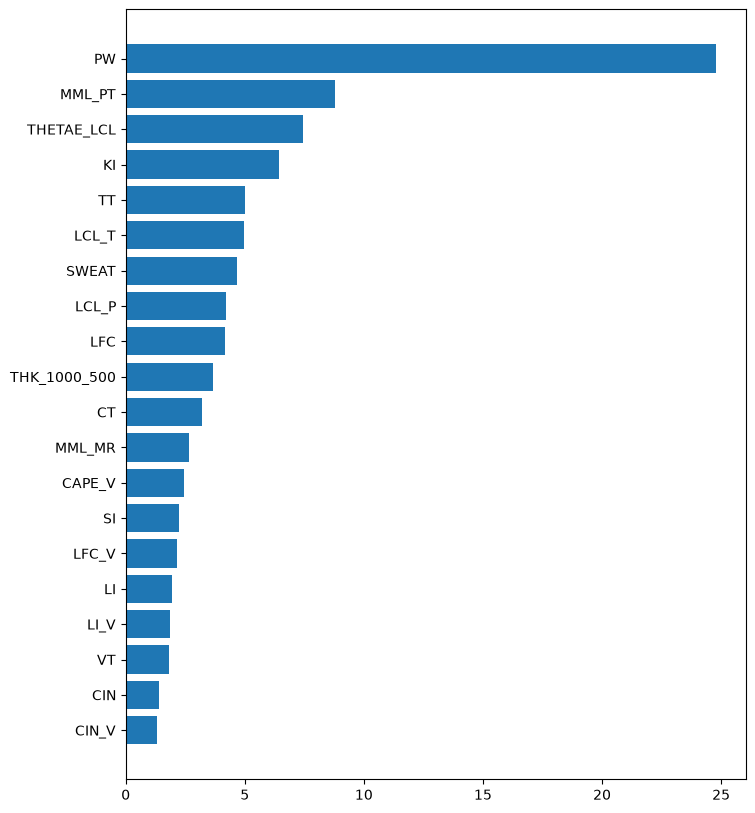

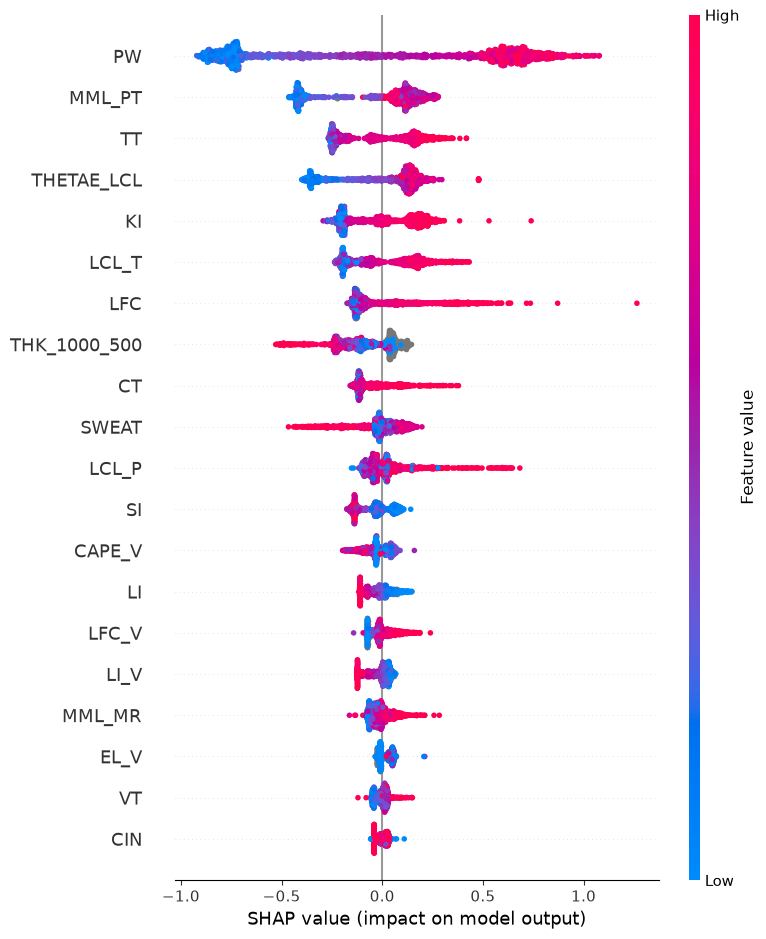

In [7]:

imp=pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.get_feature_importance()
}).sort_values("Importance",ascending=False)

display(imp)

plt.figure(figsize=(8,10))
plt.barh(imp.head(20)["Feature"],imp.head(20)["Importance"])
plt.gca().invert_yaxis()
plt.show()

explainer=shap.TreeExplainer(model)
values=explainer.shap_values(X_test)
shap.summary_plot(values,X_test)


In [8]:

joblib.dump(model,DATA/"CatBoost_Final_Research_Model.pkl")

pred=test.copy()
pred["Probability"]=test_prob
pred["Prediction"]=test_pred
pred.to_csv(DATA/"Final_Test_Predictions.csv",index=False)

print("Model and predictions saved.")


Model and predictions saved.


In [2]:
import pandas as  pd

In [6]:
import pandas as pd

train_df = pd.read_csv("../Data/train_2000_2020.csv")

train_df = train_df.drop(columns=["Date","Time"])

TARGET = "Thunderstorm_24h"

X_train = train_df.drop(columns=[TARGET])

In [8]:
import joblib

cat_model = joblib.load("../Data/CatBoost_Final_Research_Model.pkl")

In [10]:
import os

In [13]:
# ============================================================
# FEATURE RANKING
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": cat_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(drop=True)

feature_importance.index += 1

feature_importance.index.name = "Rank"

display(feature_importance)

,Feature,Importance
Rank,,
1,PW,24.793223
2,MML_PT,8.774427
3,THETAE_LCL,7.464047
4,KI,6.439376
5,TT,5.020140
6,LCL_T,4.965786
7,SWEAT,4.681135
8,LCL_P,4.192091
9,LFC,4.188094
